## Simplified self-attention

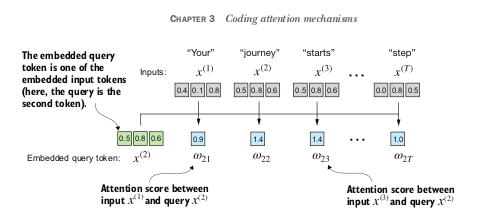   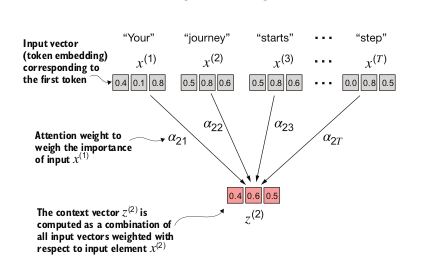   

Idea is to generate context vector (so new embedding for certain token) based on value of other tokens in the input - to give "context" to each token, based on whole input.  
Steps for each input embedding (called query):
- calculate **attention score** between query and rest of tokens (token embeddings), output would be an array of w21, w22, w23, w2x attention scores for each query
- normalize scores with softmax to **attention weights**; it says how important is some token to the query
- multiply each token (embedding) with it's attention weight - it will result in **context vector**; it has information from all input tokens within

Code example for one of the tokens (x2):

In [11]:
import torch

inputs = torch.tensor(
[[0.43, 0.15, 0.89], # x1 # Your
[0.55, 0.87, 0.66],  # x2 # journey
[0.57, 0.85, 0.64],  # x3 # starts
[0.22, 0.58, 0.33],  # x4 # with
[0.77, 0.25, 0.10],  # x5 # one
[0.05, 0.80, 0.55]]  # x6 # step
)

x2 = inputs[1]
x2_att_scores = torch.empty(inputs.shape[0]) # how closely related is each of the embeddings (x1,x2,x3,x4,x5,x6) with x2

for idx, _ in enumerate(inputs):
    x2_att_scores[idx] = torch.dot(x2, inputs[idx])

x2_att_weights = torch.softmax(x2_att_scores, 0) # normalized scores
z2 = torch.zeros(x2.shape)

for idx, _ in enumerate(inputs):
    z2 += x2_att_weights[idx] * inputs[idx]
    
print(inputs)
print(x2_att_scores)
print(x2_att_weights)
print(z2)


tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])
tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
tensor([0.4419, 0.6515, 0.5683])


## Self-attention with trainable weights

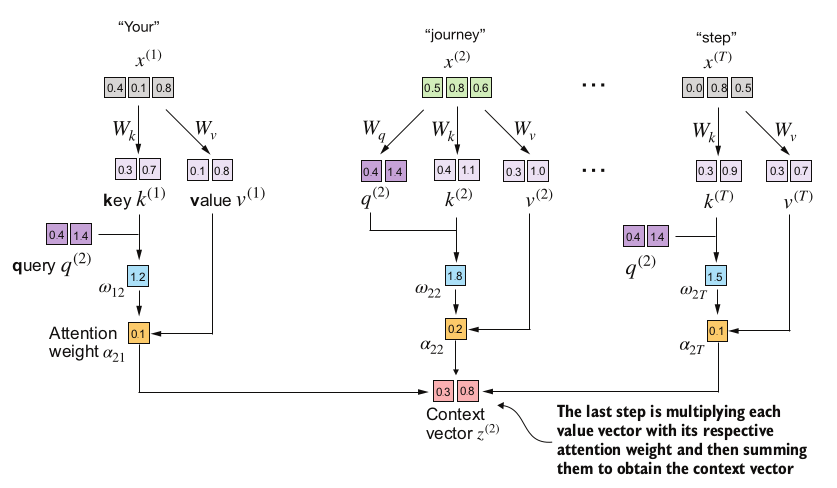

Idea is to generate 3 embeddings out of each token -> query (q), key (k) and value (v) size (arbitriary selected) of 2 using trainable weight matrices W<sub>q</sub>, W<sub>k</sub>, W<sub>v</sub>.  
Those matrices have size of 3x2 to  fit into matrix multiplication requirements.
After that we do similar steps as before - so we calculate attention weights, **BUT** using query _q<sub>2</sub>_ instead of x<sub>2</sub> and multiply it with key _k<sub>2</sub>_  (and normalize afterwards)
After weights are calculated, context vector is obtained by multiplying weight with each value vector _v<sub>x</sub>_

In [12]:
inputs = torch.tensor(
[[0.43, 0.15, 0.89], # x1 # Your
[0.55, 0.87, 0.66],  # x2 # journey
[0.57, 0.85, 0.64],  # x3 # starts
[0.22, 0.58, 0.33],  # x4 # with
[0.77, 0.25, 0.10],  # x5 # one
[0.05, 0.80, 0.55]]  # x6 # step
)
d_in = inputs.shape[1]
x_2 = inputs[1]
d_out = 2

torch.manual_seed(123)
W_q = torch.nn.Parameter(torch.rand((d_in, d_out))) 
W_k = torch.nn.Parameter(torch.rand((d_in, d_out)))
W_v = torch.nn.Parameter(torch.rand((d_in, d_out))) 

query_2 = x_2 @ W_q # single transformation frm x_2 to query using W_q

queries = inputs @ W_q
keys = inputs @ W_k
values = inputs @ W_v

keys_2 = keys[1]
d_k = keys.shape[1] #2
print(keys.shape)
attn_score_22 = torch.dot(query_2, keys_2)
attn_scores_2 = query_2 @ keys.T
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
context_vec_2 = attn_weights_2 @ values

# print(x_2)
# print(W_q)
# print(query_2)
# print(queries)
# print(keys)
# print(values)
print(context_vec_2)

torch.Size([6, 2])
tensor([0.3061, 0.8210], grad_fn=<SqueezeBackward4>)


## Self-attention class

In [19]:
import torch.nn as nn

class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = torch.nn.Linear(d_in, d_out, bias = qkv_bias) 
        self.W_key = torch.nn.Linear(d_in, d_out, bias = qkv_bias)
        self.W_value = torch.nn.Linear(d_in, d_out, bias = qkv_bias) 


    def forward(self, x):
        queries = self.W_query(inputs)
        keys = self.W_key(inputs)
        values = self.W_value(inputs)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)
        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(123)
sa_v1 = SelfAttention_v2(d_in, d_out)
print(sa_v1(inputs))


tensor([[-0.5337, -0.1051],
        [-0.5323, -0.1080],
        [-0.5323, -0.1079],
        [-0.5297, -0.1076],
        [-0.5311, -0.1066],
        [-0.5299, -0.1081]], grad_fn=<MmBackward0>)
